## Planning Algorithms in AI 
## PS1: Discrete Planning

Student: Olga Tiupina
Problem: Find the best way to find a path for an object in 2D space with obstacles, consider different heuristic function for A* algorithm, build C-space.
 

## PART I
### Configuration Space

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from utils import plot_enviroment
import astar_planner

data = np.load('data_ps1.npz')
environment = data['environment']  
rod = data['rod'] 

print(f"Environment shape: {environment.shape}")
print(f"Rod shapes: {rod.shape}")

[[1. 1. 1. ... 1. 1. 1.]
 [1. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 1.]
 ...
 [1. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 1.]
 [1. 1. 1. ... 1. 1. 1.]]
Environment shape: (100, 100)
Rod shapes: (11, 11, 4)


### A: Visualize workspace and rod configurations


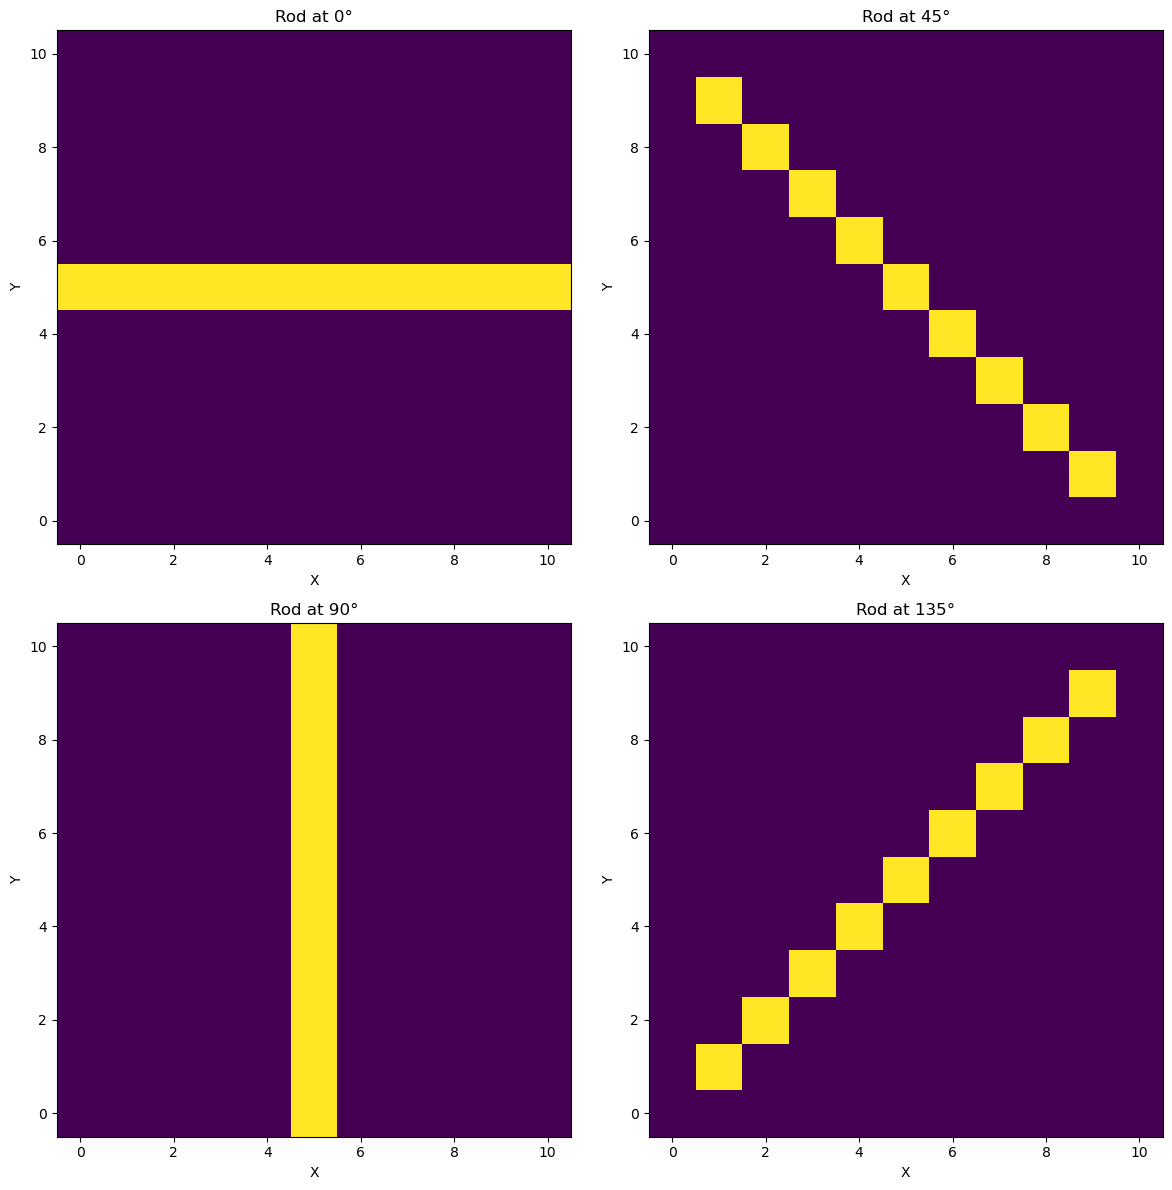

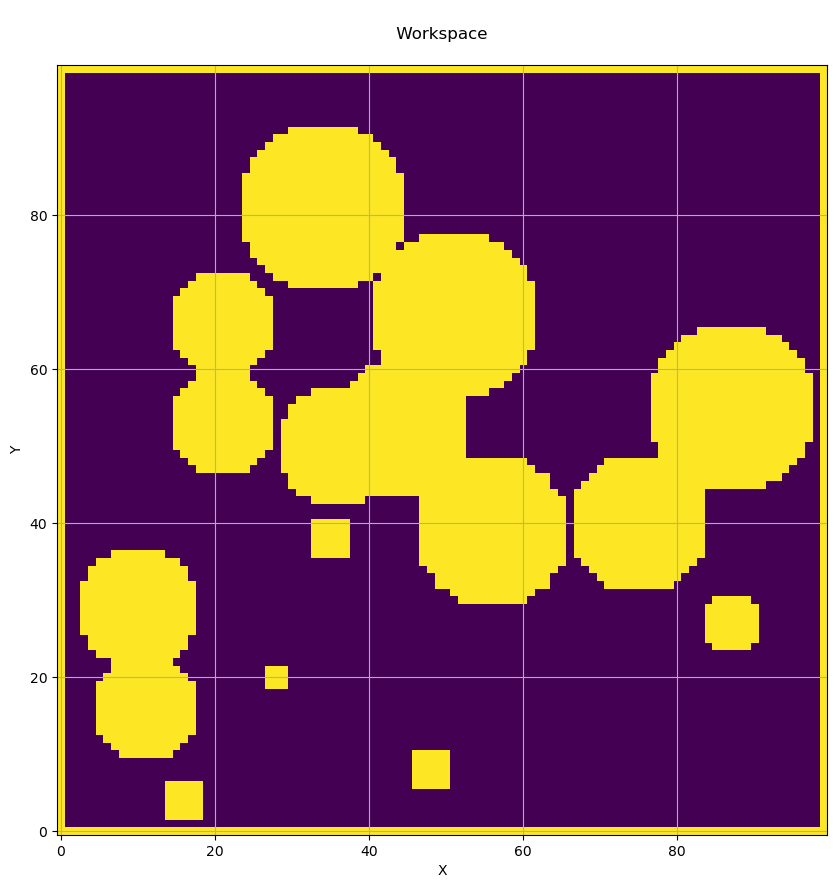

In [2]:
def part_A():
    fig, axes = plt.subplots(2, 2, figsize=(12, 12)) 
    
    orientations = [0, 45, 90, 135]
    
    for i, angle in enumerate(orientations):
        row = i // 2
        col = i % 2
        axes[row, col].imshow(rod[:, :, i], cmap='viridis', origin='lower')
        axes[row, col].set_title(f'Rod at {angle}°')
        axes[row, col].set_xlabel('X')
        axes[row, col].set_ylabel('Y')
    
    plt.tight_layout()
    plt.show()


    # # Plot workspace
    plt.figure(figsize=(20, 10))
    plt.imshow(environment, cmap='viridis', origin='lower')
    plt.title('\n Workspace \n')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.show()
    

part_A()

Environment is grid, where 0 value is free space, 1 value is obstacle. Size: (100, 100).
Rod is stick, which can rotate in the environment. Length of the stick is 11x1. Possible discreate angles are 0, 45, 90, 135.

### B: Visualize environment with object


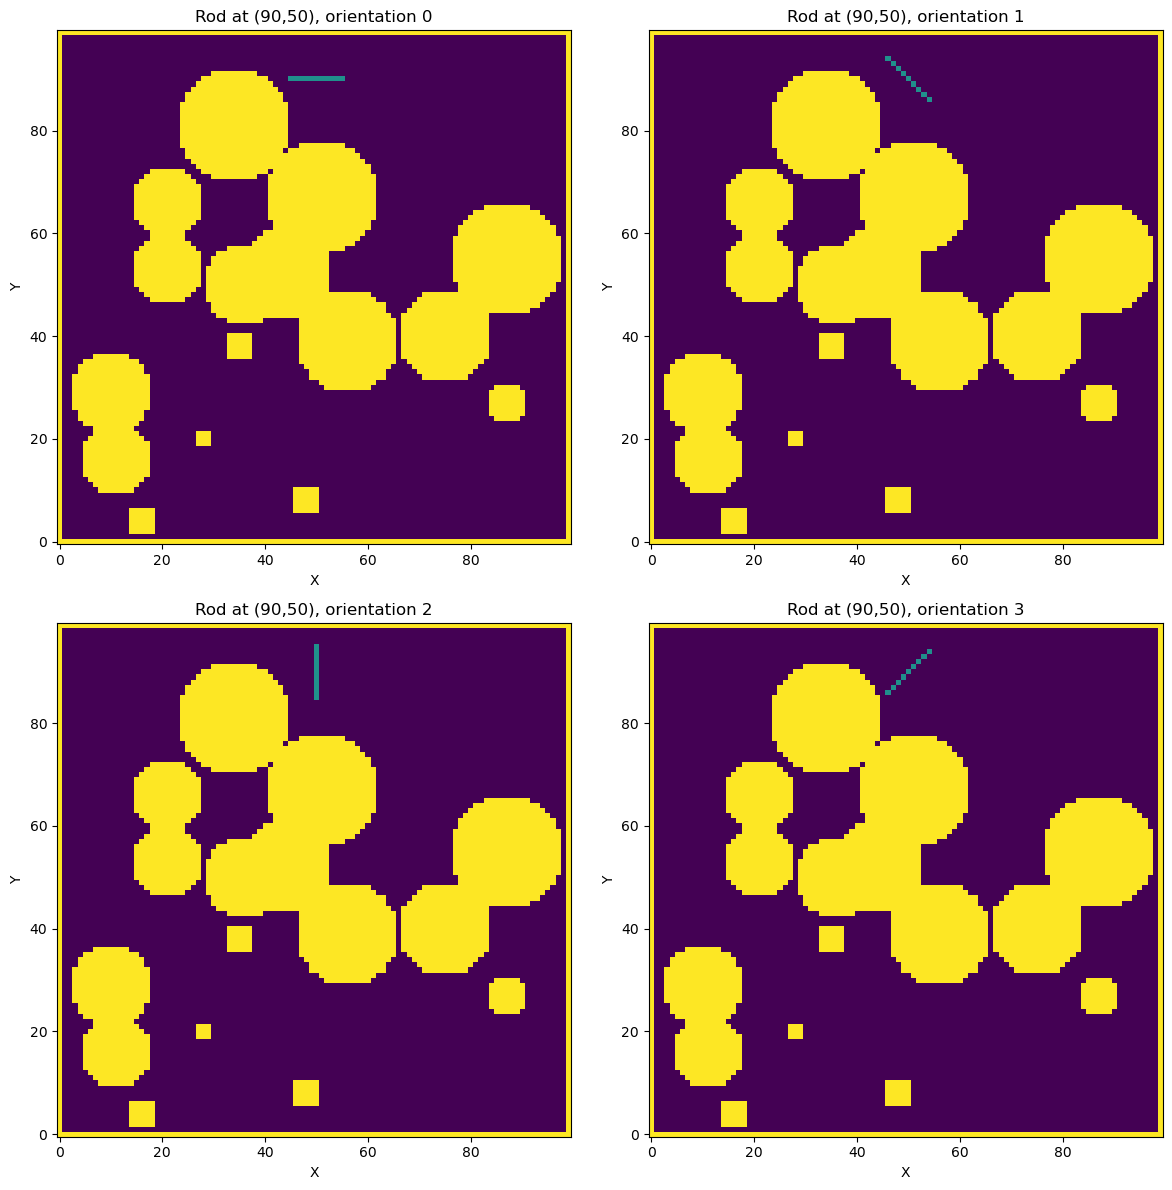

In [3]:
def part_B():

    configs = [
        [90, 50, 0],   # (0=0°)
        [90, 50, 1],   # (1=45°)
        [90, 50, 2],   # (2=90°)
        [90, 50, 3]    # (3=135°)
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    for i, config in enumerate(configs):
        row = i // 2
        col = i % 2
        merged_img = plot_enviroment(environment, rod, config)
        axes[row, col].imshow(merged_img, cmap='viridis', origin='lower')
        axes[row, col].set_title(f'Rod at ({config[0]},{config[1]}), orientation {config[2]}')
        axes[row, col].set_xlabel('X')
        axes[row, col].set_ylabel('Y')
    
    plt.tight_layout()
    plt.show()

part_B()

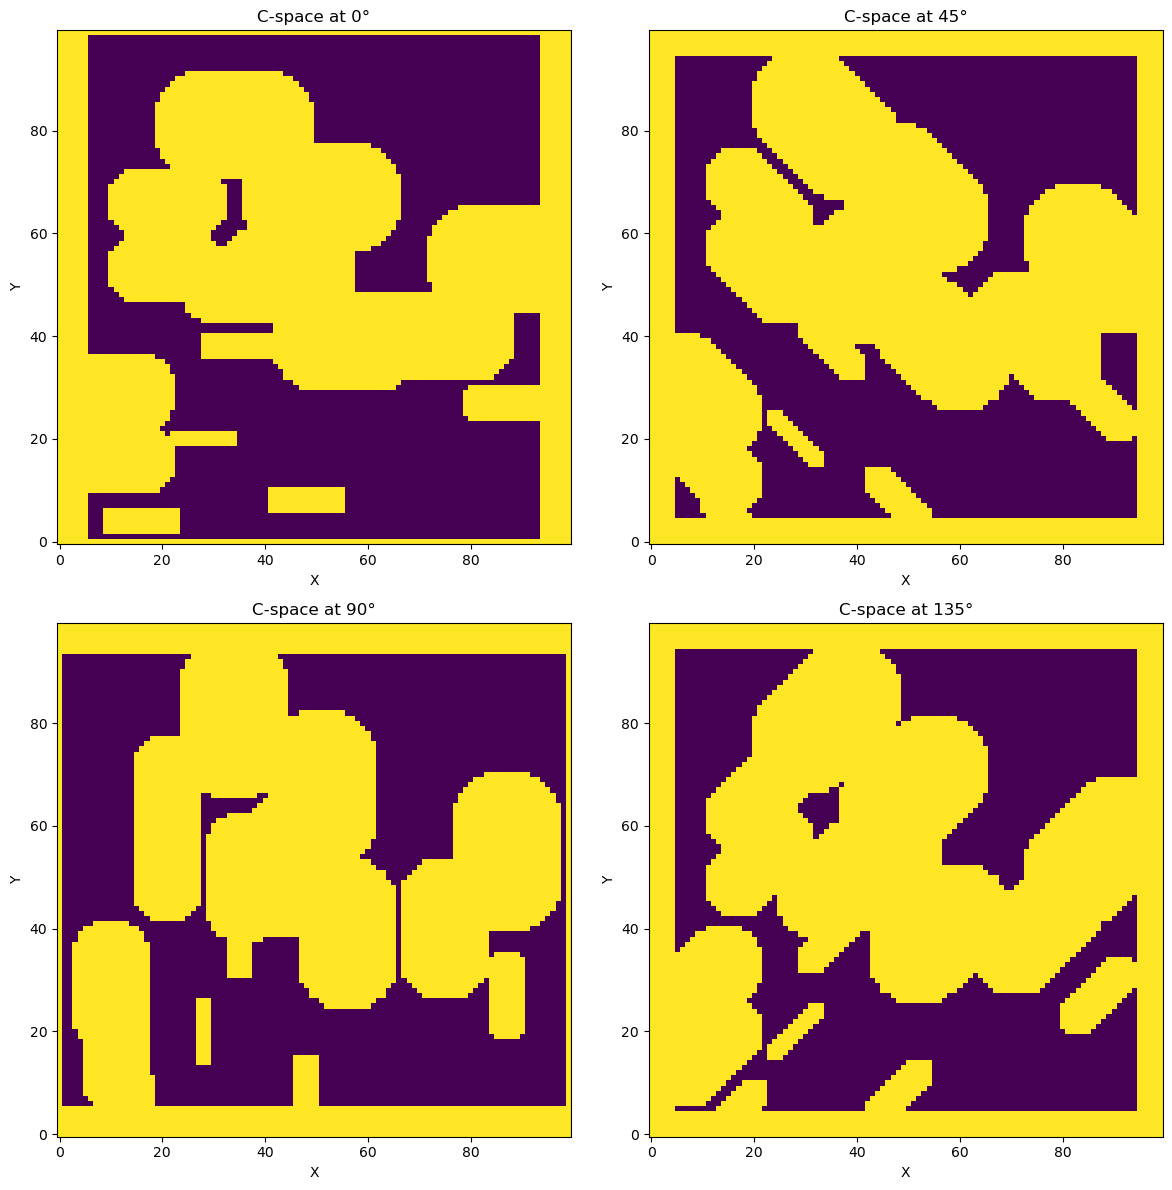

In [4]:

def part_C_cpp():
    data = np.load('data_ps1.npz')
    environment, rod = data['environment'], data['rod']
    
    environment_list = environment.astype(int).tolist()
    rod_list = [rod[:, :, i].astype(int).tolist() for i in range(rod.shape[2])]
    
    cspace_list = astar_planner.compute_cspace(environment_list, rod_list)
    
    c_space = np.stack([np.array(mat) for mat in cspace_list], axis=2)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    orientations = [0, 45, 90, 135]
    
    for i, angle in enumerate(orientations):
        row = i // 2
        col = i % 2
        axes[row, col].imshow(c_space[:, :, i], cmap='viridis', origin='lower')
        axes[row, col].set_title(f'C-space at {angle}°')
        axes[row, col].set_xlabel('X')
        axes[row, col].set_ylabel('Y')
    
    plt.tight_layout()
    plt.show()
    
    return c_space

c_space = part_C_cpp()

### D: Comment on obtained C-space

C-space: (100, 100, 4)
C-space consists of 3-dimensions: x, y and angle axes.
  - Spatial dimensions: 100 × 100 = 10,000 positions
  - Orientations: 4 discrete angles

Observations:
1. The C-space expands the original 2D workspace to include orientation
2. Each orientation has different obstacle expansion patterns
3. Diagonal orientations (45°, 135°) typically have larger obstacle regions
4. The convolution method effectively 'grows' obstacles to account for stick size
5. C-space representation simplifies collision checking to point-in-space queries

Practical implications:
- Path planning must consider both position and orientation
- Some positions may be reachable only at certain orientations
- The discretization provides a searchable space for algorithms like A*

## PART II
### A star Algorithm

In [ ]:
start_x, start_y, start_theta = 6, 6, 2
goal_x, goal_y, goal_theta = 85, 85, 0

# to C++ format
environment_list = environment.astype(int).tolist()
rod_list = [rod[:, :, i].astype(int).tolist() for i in range(rod.shape[2])]


In [6]:
def plot_path(environment, path, title="Path"):
    plt.figure(figsize=(12, 10))
    
    plt.imshow(environment, cmap='viridis', origin='lower', alpha=0.7)
    
    if len(path) > 0:
        path_array = np.array(path)
        plt.plot(path_array[:, 0], path_array[:, 1], c='black', linewidth=2, label='Path')
        plt.scatter([start_x], [start_y], c='black', s=50, marker='o', label='Start')
        plt.scatter([goal_x], [goal_y], c='black', s=50, marker='s', label='Goal')
        
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### Dijkstra algorithm

Using Dijkstra heuristic
Starting path finding...
Found the path!
Final cost is 159.5
Num of states is 16253
Path length is 162


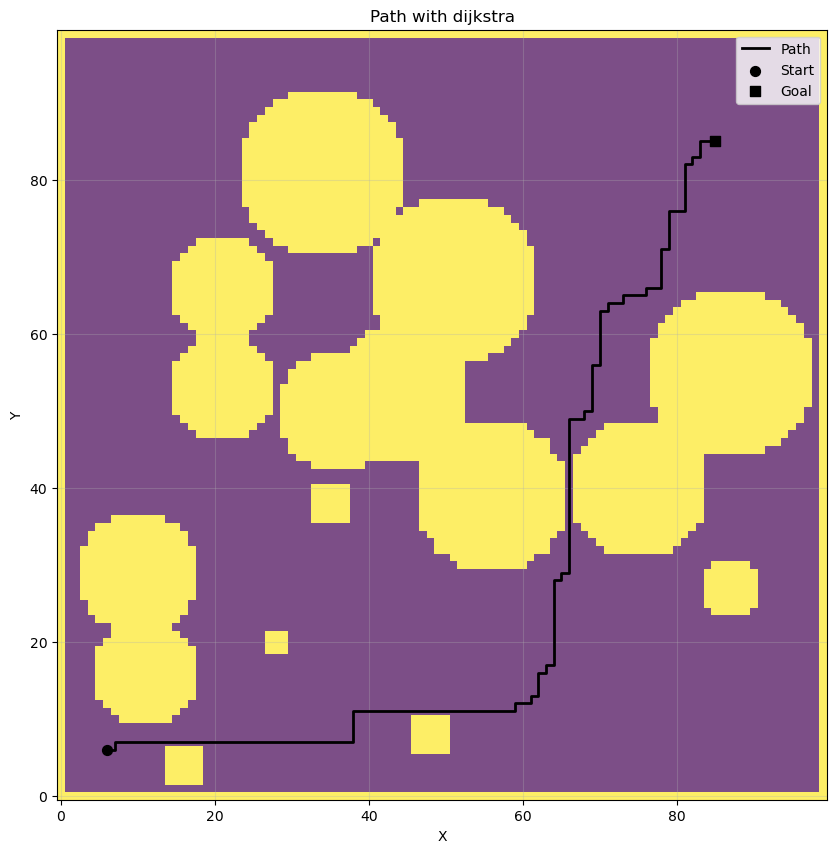

In [7]:
planner_zero = astar_planner.AStar(environment_list, rod_list, "dijkstra")
path_zero = planner_zero.find_path(start_x, start_y, start_theta, goal_x, goal_y, goal_theta)
plot_path(environment, path_zero, "Path with dijkstra")

MovieWriter ffmpeg unavailable; using Pillow instead.


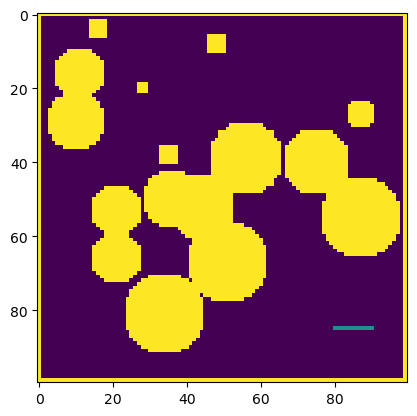

In [8]:
if len(path_zero) > 0:
    from utils import plotting_results
    plan_for_animation = [(step[1], step[0], step[2]) for step in path_zero]
    plotting_results(environment, rod, plan_for_animation, 'rod_solve.gif')

Final cost of the dijkstra alg is 161. Number of dijkstra visited states is 16259.

### A* algorithm with manhattan heuristic

Using Manhattan heuristic
Starting path finding...
Found the path!
Final cost is 160
Num of states is 6513
Path length is 163


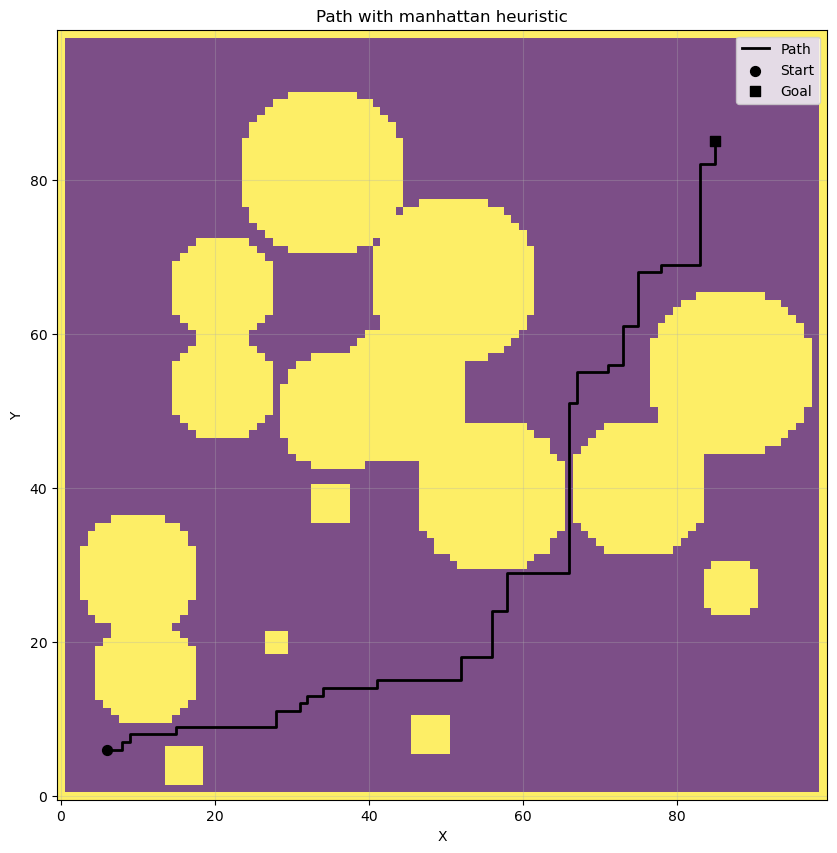

In [9]:
#  manhattan heuristic
planner_manhattan = astar_planner.AStar(environment_list, rod_list, "manhattan")
path_manhattan = planner_manhattan.find_path(start_x, start_y, start_theta, goal_x, goal_y, goal_theta)
plot_path(environment, path_manhattan, "Path with manhattan heuristic")


Final cost of A* is 161. Number of A* visited states is 5857 (dijkstra visited states are 16259).


### A* algorithm with heuristic depends on orientation

Using angle depend heuristic
Starting path finding...
Found the path!
Final cost is 159.5
Num of states is 4756
Path length is 162


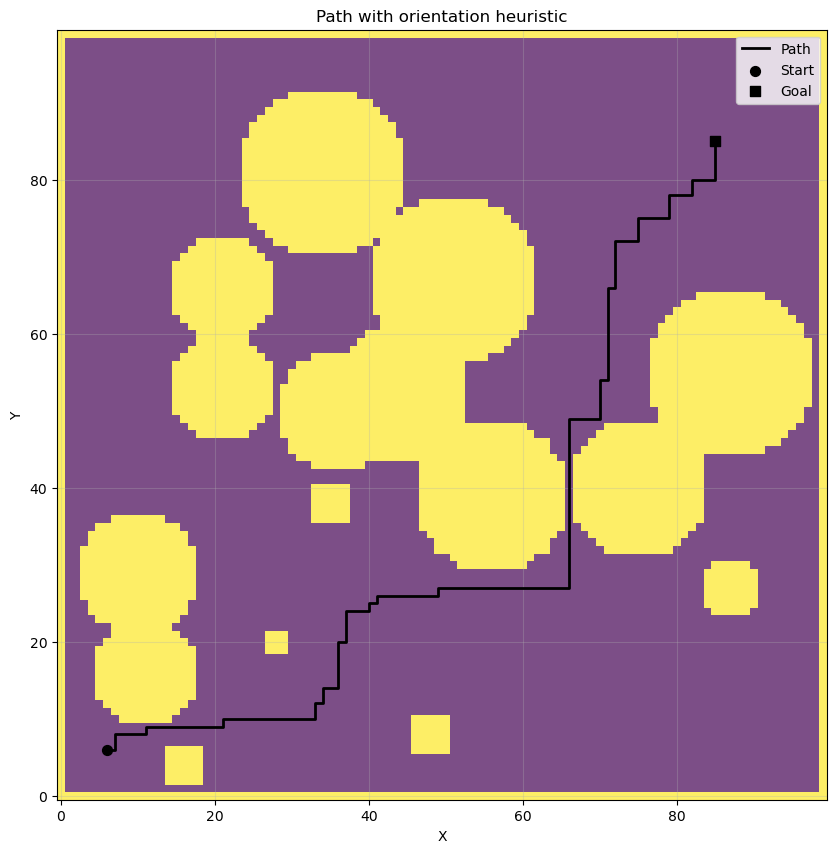

In [10]:
planner_orientation = astar_planner.AStar(environment_list, rod_list, "orientation")
path_orientation = planner_orientation.find_path(start_x, start_y, start_theta, goal_x, goal_y, goal_theta)
plot_path(environment, path_orientation, "Path with orientation heuristic")


In the last method heuristic including orientation was used. The heuristic uses both orientation with coefficient and position. Coefficient was used to equalize the influence of position and angle on the cost of a node. Final cost is 161, number of visited states is 4739.